[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdsanch1/simrc/blob/master/02.%20Parte%202/12.%20Clase%2012/12Class%20NB.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/jdsanch1/SimRC/master?labpath=02.%20Parte%202%2F12.%20Clase%2012%2F12Class%20NB.ipynb)

In [ ]:
import importlib, subprocess, sys

_required = ["yfinance", "pandas", "numpy", "matplotlib", "seaborn", "scipy", "sklearn", "statsmodels"]
_missing  = [pkg for pkg in _required if importlib.util.find_spec(pkg) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)

# Clase 12:	Estrategias relacionadas con opciones

[Juan Diego Sánchez Torres](https://www.researchgate.net/profile/Juan_Diego_Sanchez_Torres), 

*Profesor*, [MAF ITESO](http://maf.iteso.mx/web/general/detalle?group_id=5858156)

+ Departamento de Matemáticas y Física
+ dsanchez@iteso.mx
+ Tel. 3669-34-34 Ext. 3069
+ Oficina: Cubículo 4, Edificio J, 2do piso

In [1]:
#importar los paquetes que se van a usar
import pandas as pd
import yfinance as yf
import numpy as np
import datetime
from datetime import datetime
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#algunas opciones para Python
pd.set_option('display.notebook_repr_html', True)
pd.set_option('display.max_columns', 6)
pd.set_option('display.max_rows', 10)
pd.set_option('display.width', 78)
pd.set_option('precision', 3)

# 1. Gráficos del *Pay Off* de opciones Call y Put europeas

En primer lugar, para poder bajar precios y información sobre opciones de Yahoo, es necesario cargar algunos paquetes de Python. En este caso, el paquete principal será Pandas. También, se usarán el Scipy y el Numpy para las matemáticas necesarias y, el Matplotlib y el Seaborn para hacer gráficos de las series de datos.

In [2]:
def call_payoff(ST, K):
    return max(0, ST-K)

In [3]:
call_payoff(25, 30)

0

In [4]:
def call_payoffs(STmin, STmax, K, step=1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs = np.vectorize(call_payoff)(maturities, K)
    df = pd.DataFrame({'Strike': K, 'Payoff': payoffs}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df

In [5]:
call_payoffs(10,25,15)

,Payoff,Strike
Precio de maduración,,
10,0,15
11,0,15
12,0,15
13,0,15
14,0,15
...,...,...
21,6,15
22,7,15
23,8,15


In [6]:
def plot_call_payoffs(STmin, STmax, K, step=1):
    payoffs = call_payoffs(STmin, STmax, K, step)
    plt.ylim(payoffs.Payoff.min() - 10, payoffs.Payoff.max() + 10)
    plt.ylabel("Payoff")
    plt.xlabel("Precio de maduración")
    plt.title('Payoff call, Precio strike={0}'.format(K))
    plt.xlim(STmin, STmax)
    plt.plot(payoffs.index, payoffs.Payoff.values);

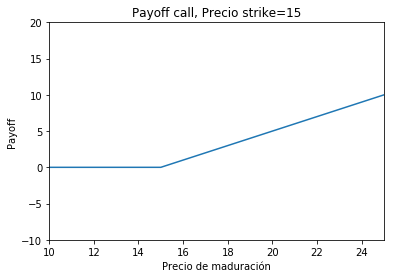

In [7]:
plot_call_payoffs(10, 25, 15)

In [8]:
def put_payoff(ST, K):
    return max(0, K-ST)

In [9]:
put_payoff(25, 30)

5

In [10]:
def put_payoffs(STmin, STmax, K, step=1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs = np.vectorize(put_payoff)(maturities, K)
    df = pd.DataFrame({'Strike': K, 'Payoff': payoffs}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df

In [11]:
put_payoffs(10,25,15)

,Payoff,Strike
Precio de maduración,,
10,5,15
11,4,15
12,3,15
13,2,15
14,1,15
...,...,...
21,0,15
22,0,15
23,0,15


In [12]:
def plot_put_payoffs(STmin, STmax, K, step=1):
    payoffs = put_payoffs(STmin, STmax, K, step)
    plt.ylim(payoffs.Payoff.min() - 10, payoffs.Payoff.max() + 10)
    plt.ylabel("Payoff")
    plt.xlabel("Precio de maduración")
    plt.title('Payoff put, Precio strike={0}'.format(K))
    plt.xlim(STmin, STmax)
    plt.plot(payoffs.index, payoffs.Payoff.values);

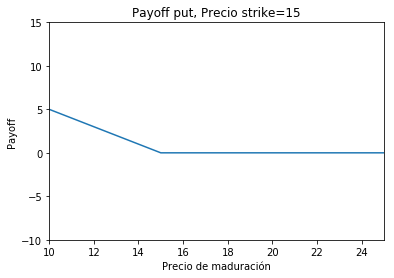

In [13]:
plot_put_payoffs(10, 25, 15)

In [14]:
def call_pnl_buyer(ct, K, STmin, STmax, step = 1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs = np.vectorize(call_payoff)(maturities, K)
    df = pd.DataFrame({'Strike': K, 'Payoff': payoffs, 'Prima': ct, 'PnL': payoffs-ct}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df


In [15]:
call_pnl_buyer(12, 15, 10, 35)

,Payoff,PnL,Prima,Strike
Precio de maduración,,,,
10,0,-12,12,15
11,0,-12,12,15
12,0,-12,12,15
13,0,-12,12,15
14,0,-12,12,15
...,...,...,...,...
31,16,4,12,15
32,17,5,12,15
33,18,6,12,15


In [16]:
def call_pnl_seller(ct, K, STmin, STmax, step = 1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs = np.vectorize(call_payoff)(maturities, K)
    df = pd.DataFrame({'Strike': K, 'Payoff': payoffs, 'Prima': ct, 'PnL': ct-payoffs}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df

In [17]:
call_pnl_seller(12, 15, 10, 35)

,Payoff,PnL,Prima,Strike
Precio de maduración,,,,
10,0,12,12,15
11,0,12,12,15
12,0,12,12,15
13,0,12,12,15
14,0,12,12,15
...,...,...,...,...
31,16,-4,12,15
32,17,-5,12,15
33,18,-6,12,15


In [18]:
def call_pnl_combined(ct, K, STmin, STmax, step = 1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs = np.vectorize(call_payoff)(maturities, K)
    df = pd.DataFrame({'Strike': K, 'Payoff': payoffs, 'Prima': ct, 'PnLcomprador': payoffs-ct, 'PnLvendedor': ct-payoffs}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df

In [19]:
call_pnl_combined(12, 15, 10, 35)

,Payoff,PnLcomprador,PnLvendedor,Prima,Strike
Precio de maduración,,,,,
10,0,-12,12,12,15
11,0,-12,12,12,15
12,0,-12,12,12,15
13,0,-12,12,12,15
14,0,-12,12,12,15
...,...,...,...,...,...
31,16,4,-4,12,15
32,17,5,-5,12,15
33,18,6,-6,12,15


In [20]:
def put_pnl_buyer(ct, K, STmin, STmax, step = 1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs = np.vectorize(put_payoff)(maturities, K)
    df = pd.DataFrame({'Strike': K, 'Payoff': payoffs, 'Prima': ct, 'PnL': payoffs-ct}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df

In [21]:
put_pnl_buyer(2, 15, 10, 30)

,Payoff,PnL,Prima,Strike
Precio de maduración,,,,
10,5,3,2,15
11,4,2,2,15
12,3,1,2,15
13,2,0,2,15
14,1,-1,2,15
...,...,...,...,...
26,0,-2,2,15
27,0,-2,2,15
28,0,-2,2,15


In [22]:
def put_pnl_seller(ct, K, STmin, STmax, step = 1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs = np.vectorize(put_payoff)(maturities, K)
    df = pd.DataFrame({'Strike': K, 'Payoff': payoffs, 'Prima': ct, 'PnL': ct-payoffs}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df

In [23]:
put_pnl_seller(2, 15, 10, 30)

,Payoff,PnL,Prima,Strike
Precio de maduración,,,,
10,5,-3,2,15
11,4,-2,2,15
12,3,-1,2,15
13,2,0,2,15
14,1,1,2,15
...,...,...,...,...
26,0,2,2,15
27,0,2,2,15
28,0,2,2,15


In [24]:
def put_pnl_combined(ct, K, STmin, STmax, step = 1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs = np.vectorize(put_payoff)(maturities, K)
    df = pd.DataFrame({'Strike': K, 'Payoff': payoffs, 'Prima': ct, 'PnLcomprador': payoffs-ct, 'PnLvendedor': ct-payoffs}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df

In [25]:
put_pnl_combined(2, 15, 10, 30)

,Payoff,PnLcomprador,PnLvendedor,Prima,Strike
Precio de maduración,,,,,
10,5,3,-3,2,15
11,4,2,-2,2,15
12,3,1,-1,2,15
13,2,0,0,2,15
14,1,-1,1,2,15
...,...,...,...,...,...
26,0,-2,2,2,15
27,0,-2,2,2,15
28,0,-2,2,2,15


In [26]:
def plot_pnl(pnl_df, okind, who):
    plt.ylim(pnl_df.Payoff.min() - 10, pnl_df.Payoff.max() + 10)
    plt.ylabel("Ganancia/pérdida")
    plt.xlabel("Precio de maduración")
    plt.title('Ganancia y pérdida de una opción {0} para el {1}, Prima={2}, Strike={3}'.format(okind, who, pnl_df.Prima.iloc[0],
    pnl_df.Strike.iloc[0]))
    plt.ylim(pnl_df.PnL.min()-3, pnl_df.PnL.max() + 3)
    plt.xlim(pnl_df.index[0], pnl_df.index[len(pnl_df.index)-1])
    plt.plot(pnl_df.index, pnl_df.PnL)
    plt.axhline(0, color='g');

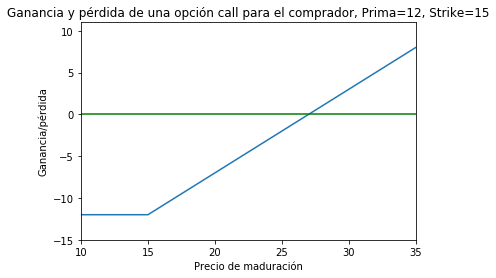

In [27]:
plot_pnl(call_pnl_buyer(12, 15, 10, 35), "call", "comprador")

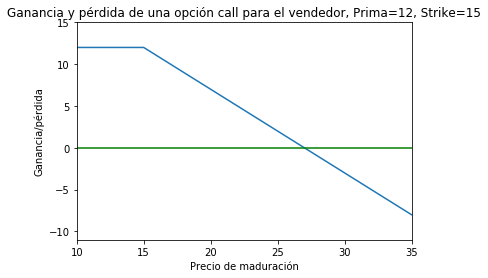

In [28]:
plot_pnl(call_pnl_seller(12, 15, 10, 35), "call", "vendedor")

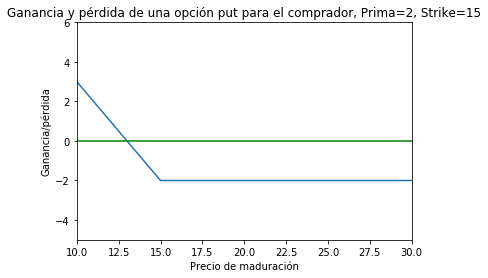

In [29]:
plot_pnl(put_pnl_buyer(2, 15, 10, 30), "put", "comprador")

# 2. Gráficos de estrategias

**Ejemplo (Hull)** Un inversionista adquiere en $\$3$ una opción de compra a tres meses con un precio de ejercicio de $\$30$, y vende en $\$1$ una opción de compra a tres meses con un precio de $\$35$. El beneficio derivado de esta estrategia de diferencial alcista es de $\$5$ si el precio de la acción esta por encima de $\$35$ y de cero si está por debajo de $\$30$. Si el precio de la acción está entre $\$30$ y $\$35$, el beneficio es la cantidad en la cual el precio de ejercicio excede a $\$30$. El costo de la estategia es de $\$2$, por tanto la utilidad es de 

Un inversionista adquiere en $\$3$ una opción de compra a tres meses con un precio de ejercicio de $\$30$

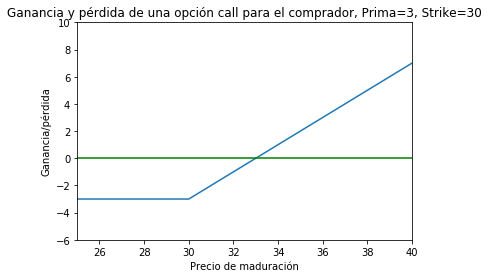

In [30]:
plot_pnl(call_pnl_buyer(3, 30, 25, 40), "call", "comprador")

Vende en $\$1$ una opción de compra a tres meses con un precio de $\$35$

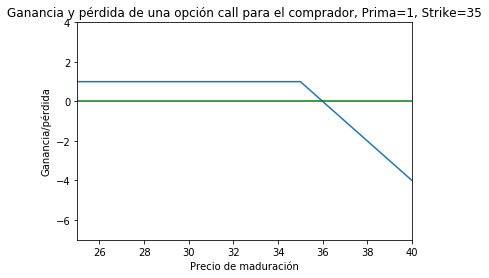

In [31]:
plot_pnl(call_pnl_seller(1, 35, 25, 40), "call", "comprador")

In [32]:
def bull_call(ct_short, K_short, ct_long, K_long, STmin, STmax, step = 1):
    maturities = np.arange(STmin, STmax+step, step)
    payoffs_cl = np.vectorize(call_payoff)(maturities, K_long)
    payoffs_cs = np.vectorize(call_payoff)(maturities, K_short)
    df = pd.DataFrame({'Strike': K_long, 'Payoff': payoffs_cs, 'Prima': ct_long-ct_short, 'PnL': payoffs_cl-ct_long+(ct_short-payoffs_cs)}, index=maturities)
    df.index.name = 'Precio de maduración'
    return df

El beneficio derivado de esta estrategia de diferencial alcista es de $\$5$ si el precio de la acción esta por encima de $\$35$ y de cero si está por debajo de $\$30$. Si el precio de la acción está entre $\$30$ y $\$35$, el beneficio es la cantidad en la cual el precio de ejercicio excede a $\$30$. El costo de la estategia es de $\$2$, por tanto la utilidad es de

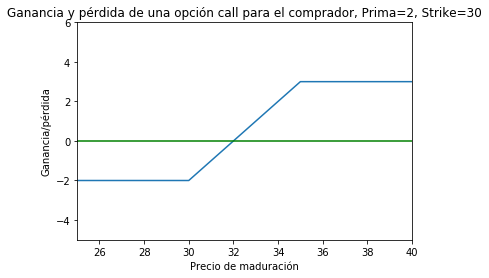

In [33]:
plot_pnl(bull_call(1, 35, 3, 30, 25, 40), "call", "comprador")